# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [1]:


# # Due to problems with TensorFlow's GPU implementation, I completely rewrote the cells to a single large functions.
# # Mainly had to remove all TensorFlow imports and GPU stuff from the global scope because of GPU memory issues (TensorFlow would eventually use up all memory)
# # All cells except this one and the last two now contain only function definitions and are used in the last two cells.

# import os, glob, ctypes, sysconfig

# # 1. Inject the Windows/WSL bridge
# ctypes.CDLL("/usr/lib/wsl/lib/libcuda.so.1", mode=ctypes.RTLD_GLOBAL)

# # 2. Inject all pip-installed NVIDIA libraries
# for lib in glob.glob(os.path.join(sysconfig.get_path('purelib'), 'nvidia', '*', 'lib', '*.so*')):
#     try: ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
#     except: pass

# import multiprocessing as mp
# import pandas as pd
# import time
# import os
# import matplotlib.pyplot as plt
# import matplotlib
# import numpy as np
# ###################################
# # Write your own code here #


# ###################################
# font = {'weight' : 'bold',
#         'size'   : 12}

# matplotlib.rc('font', **font)

# single_run = False

import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
from keras.models import Sequential
from keras.optimizers import Adam

### 1.1 Generating dataset

In [2]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [3]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [4]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [5]:
no_training_epochs = 5

### 1.3 Data examination

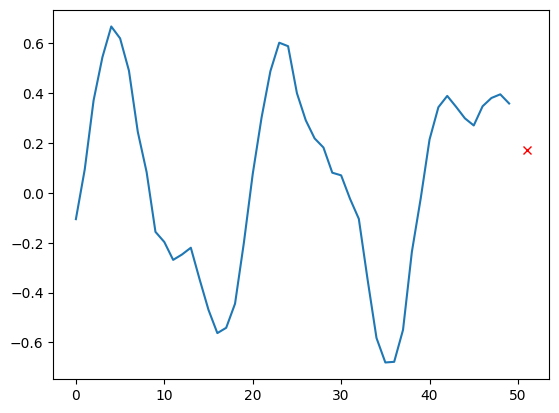

In [6]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [7]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [9]:
model_linear.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5


219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0923 - mean_squared_error: 0.0923 - val_loss: 0.0322 - val_mean_squared_error: 0.0322
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0230 - mean_squared_error: 0.0230 - val_loss: 0.0158 - val_mean_squared_error: 0.0158
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0111 - val_mean_squared_error: 0.0111
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0092 - val_mean_squared_error: 0.0092
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0081 - val_mean_squared_error: 0.0081


In [11]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

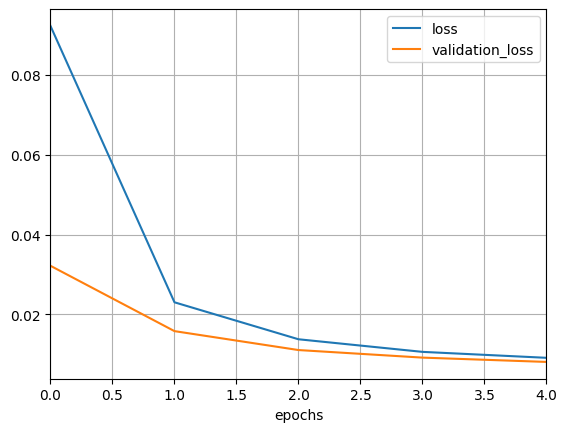

In [12]:
plot_function(history_linear)

In [13]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.007968994788825512
Test MSE:  0.007968994788825512


### 1.5 Simple RNN Model

In [14]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [16]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5


219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7353 - mean_squared_error: 0.7353 - val_loss: 0.6289 - val_mean_squared_error: 0.6289
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4391 - mean_squared_error: 0.4391 - val_loss: 0.3989 - val_mean_squared_error: 0.3989
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3433 - mean_squared_error: 0.3433 - val_loss: 0.3516 - val_mean_squared_error: 0.3516
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2998 - mean_squared_error: 0.2998 - val_loss: 0.3078 - val_mean_squared_error: 0.3078
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2646 - mean_squared_error: 0.2646 - val_loss: 0.2674 - val_mean_squared_error: 0.2674


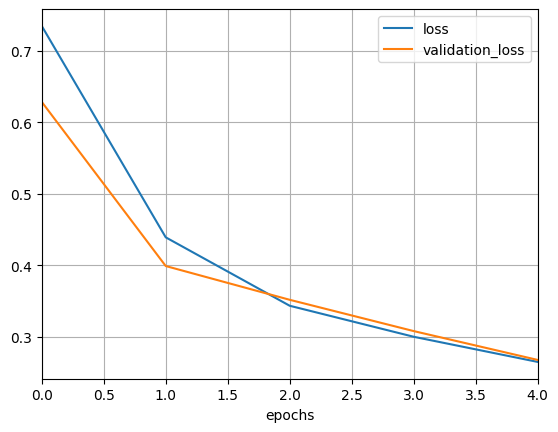

In [17]:
plot_function(history_simple_rnn)

In [18]:
score = model_simple_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.24371692538261414
Test MSE:  0.24371692538261414


### 1.5 Deep RNN Model

In [19]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [20]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [21]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5


219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0689 - mean_squared_error: 0.0689 - val_loss: 0.0099 - val_mean_squared_error: 0.0099
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0054 - val_mean_squared_error: 0.0054
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0055 - mean_squared_error: 0.0055 - val_loss: 0.0042 - val_mean_squared_error: 0.0042
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0037 - val_mean_squared_error: 0.0037
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0035 - val_mean_squared_error: 0.0035


In [22]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0037449069786816835
Test MSE:  0.0037449069786816835


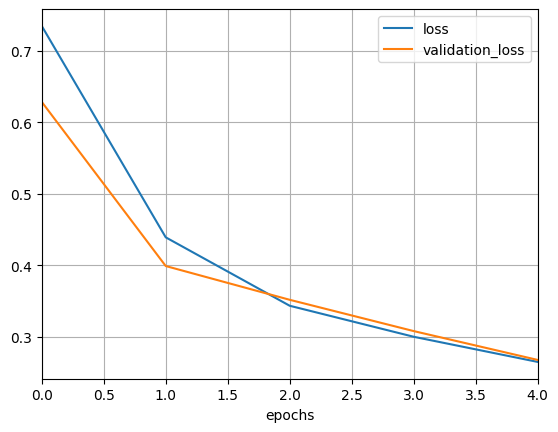

In [23]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [25]:
vocabulary_size = 1000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)
print(X_train.shape, y_train.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(25000,) (25000,)


### 2.2 - Dataset examination

In [26]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [27]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [28]:
single_sequence

"<sos> this film was just brilliant casting <unk> <unk> story direction <unk> really <unk> the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same <unk> <unk> as myself so i loved the fact there was a real <unk> with this film the <unk> <unk> throughout the film were great it was just brilliant so much that i <unk> the film as soon as it was released for <unk> and would recommend it to everyone to watch and the <unk> <unk> was amazing really <unk> at the end it was so sad and you know what they say if you <unk> at a film it must have been good and this definitely was also <unk> to the two little <unk> that played the <unk> of <unk> and paul they were just brilliant children are often left out of the <unk> <unk> i think because the stars that play them all <unk> up are such a big <unk> for the whole film but these children are amazing and should be <unk> for what they have done don't you

In [29]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [34]:
embed_size = 128


model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
optimizer = Adam(learning_rate = 0.001)

In [36]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [37]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5297 - loss: 0.6913 - val_accuracy: 0.4924 - val_loss: 0.7368
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7434 - loss: 0.4870 - val_accuracy: 0.8170 - val_loss: 0.3984
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8435 - loss: 0.3547 - val_accuracy: 0.8096 - val_loss: 0.4108
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8576 - loss: 0.3267 - val_accuracy: 0.8322 - val_loss: 0.3777
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8696 - loss: 0.3035 - val_accuracy: 0.8284 - val_loss: 0.3953


In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6931865811347961
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

In [57]:
def create_model(model_type) -> Sequential:
    model = Sequential()
    model.add(Embedding(vocabulary_size, embed_size, input_shape=[None]))
    if model_type == "SimpleRNN":
        model.add(SimpleRNN(128, return_sequences=True))
        model.add(SimpleRNN(64))
    elif model_type == "GRU":
        model.add(GRU(128, return_sequences=True))
        model.add(GRU(64))
    elif model_type == "LSTM":
        model.add(LSTM(128, return_sequences=True))
        model.add(LSTM(64))
    model.add(Dense(1, activation='sigmoid'))
    return model

In [ ]:
def run_model(model: Sequential):
    optimizer = Adam(learning_rate = 0.0001)
    model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    from tensorflow.keras.callbacks import EarlyStopping
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=30, validation_split=0.2, callbacks=[early_stopping])
    score = model.evaluate(X_test, y_test, verbose=0)
    # print('Test loss:', score[0])
    # print(f'Test accuracy: {score[1]*100:.2f}%')
    return score, history

In [63]:
simple_rnn_model = create_model("SimpleRNN")
gru_model = create_model("GRU")
lstm_model = create_model("LSTM")
print("Running SimpleRNN model...")
score_simple_rnn, history_simple_rnn = run_model(simple_rnn_model)
print("Running GRU model...")
score_gru, history_gru = run_model(gru_model)
print("Running LSTM model...")
score_lstm, history_lstm = run_model(lstm_model)

print(f"SimpleRNN test accuracy: {score_simple_rnn[1]*100:.2f}%")
print(f"GRU test accuracy: {score_gru[1]*100:.2f}%")
print(f"LSTM test accuracy: {score_lstm[1]*100:.2f}%")
print(f"Best accuracy: {max(score_simple_rnn[1], score_gru[1], score_lstm[1])*100:.2f}%")

Running SimpleRNN model...
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.5041 - loss: 0.6963 - val_accuracy: 0.5030 - val_loss: 0.6942
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.5283 - loss: 0.6900 - val_accuracy: 0.4844 - val_loss: 0.6957
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.5547 - loss: 0.6836 - val_accuracy: 0.5124 - val_loss: 0.6970
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7304 - loss: 0.5410 - val_accuracy: 0.7518 - val_loss: 0.5326
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8235 - loss: 0.4067 - val_accuracy: 0.7858 - val_loss: 0.5141
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8638 - loss: 0.3298 - val_accuracy: 0.7996 - val_loss: 0.4970
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8943 - loss: 0.2707 - val_accuracy: 0.7722 - val_loss: 0.5545
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accurac